# Cluster 6 MT_362 Direct Trend Forecasting

This notebook removes ETS/Holt-Winters from model selection. ETS is intentionally excluded because its forecast for this customer degenerated into a repeated daily seasonal curve and interfered with final model selection.

Models compared here:

1. Naive baseline
2. Direct multi-horizon LightGBM with lag, rolling, calendar, horizon, and trend-projection features
3. Direct multi-horizon XGBoost with the same feature set
4. Prophet, included as an explicit trend + seasonality model

Only validation MAPE is used for model and parameter selection. Test MAPE is evaluated once after final selection.

In [1]:
# -----------------------------
# Editable configuration
# -----------------------------
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data" / "train_hourly_preprocessed.parquet").exists():
    for candidate in PROJECT_ROOT.parents:
        if (candidate / "data" / "train_hourly_preprocessed.parquet").exists():
            PROJECT_ROOT = candidate
            break

RANDOM_SEED = 42

DATA_DIR = PROJECT_ROOT / "data"
TRAIN_PATH = DATA_DIR / "train_hourly_preprocessed.parquet"
TEST_PATH = DATA_DIR / "test_hourly_preprocessed.parquet"
CLUSTERS_PATH = DATA_DIR / "extended-clustering-high-cov" / "clusters_3models.parquet"

TIMESTAMP_COLUMN = "timestamp"
TARGET_METER_ID = "MT_362"
TARGET_COLUMN = None
CLUSTER_ID = 6
CLUSTER_COLUMN = "cluster_kmeans"

VALIDATION_HORIZON = None  # None means same length as test.
OUTPUT_DIR = PROJECT_ROOT / "cluster6/artifacts/eval/direct_trend"
PLOT_DIR = PROJECT_ROOT / "cluster6/artifacts/plots/direct_trend"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SEASONAL_LAG = 24
WEEKLY_LAG = 24 * 7
LONG_WINDOW = 24 * 30

# Direct multi-horizon training can grow quickly. These settings keep it reproducible and report-friendly.
ORIGIN_STEP_HOURS = 24
MAX_FORECAST_HORIZON = None  # None means validation/test horizon length.
MAX_DIRECT_TRAIN_ROWS = 600_000

# Match tft/src/eval/evaluate_tft.py metric handling.
MAPE_EPSILON = 1e-6

# Rolling-origin validation settings. Each origin trains only on data available at that cutoff
# and predicts the next 14 days. Test is still evaluated once without rolling updates.
ROLLING_VALIDATION_HORIZON_HOURS = 24 * 14
ROLLING_VALIDATION_ORIGINS = [
    "2014-04-30 23:00:00",
    "2014-05-31 23:00:00",
    "2014-06-30 23:00:00",
    "2014-07-31 23:00:00",
    "2014-08-31 23:00:00",
]

# Prophet can be slower than tree models, so keep its validation grid small.
RUN_PROPHET = True


In [2]:
# -----------------------------
# Imports
# -----------------------------
import json
import warnings
from itertools import product

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from prophet import Prophet
from statsmodels.graphics.tsaplots import plot_acf

warnings.filterwarnings("ignore")
np.random.seed(RANDOM_SEED)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 4)


/opt/anaconda3/envs/AML/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


## Helper Functions

In [3]:
def read_parquet_compat(path: Path) -> pd.DataFrame:
    for engine in ("fastparquet", "pyarrow"):
        try:
            return pd.read_parquet(path, engine=engine)
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"Could not read {path}: {last_error}")


def ensure_datetime_index(df: pd.DataFrame, timestamp_column: str) -> pd.DataFrame:
    out = df.copy()
    if not isinstance(out.index, pd.DatetimeIndex):
        if timestamp_column not in out.columns:
            raise ValueError(f"No DatetimeIndex and no {timestamp_column!r} column found.")
        out[timestamp_column] = pd.to_datetime(out[timestamp_column])
        out = out.set_index(timestamp_column)
    out.index = pd.to_datetime(out.index)
    return out.sort_index()


def mape(y_true, y_pred) -> float:
    yt = pd.Series(y_true).astype(float)
    yp = pd.Series(y_pred, index=yt.index).astype(float)
    mask = yt != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((yt.loc[mask] - yp.loc[mask]) / yt.loc[mask])) * 100)


def ape_pct(y_true, y_pred) -> pd.Series:
    yt = pd.Series(y_true).astype(float)
    yp = pd.Series(y_pred, index=yt.index).astype(float)
    out = pd.Series(np.nan, index=yt.index, dtype=float)
    mask = yt != 0
    out.loc[mask] = np.abs((yt.loc[mask] - yp.loc[mask]) / yt.loc[mask]) * 100
    return out


def epsilon_ape_pct(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> pd.Series:
    yt = pd.Series(y_true).astype(float)
    yp = pd.Series(y_pred, index=yt.index).astype(float)
    denom = yt.abs().clip(lower=epsilon)
    return ((yt - yp).abs() / denom) * 100.0


def mape_0_100(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> float:
    return float(epsilon_ape_pct(y_true, y_pred, epsilon).clip(lower=0.0, upper=100.0).mean())


def epsilon_mape_pct(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> float:
    return float(epsilon_ape_pct(y_true, y_pred, epsilon).mean())


def wmape_0_100(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> float:
    yt = pd.Series(y_true).astype(float)
    yp = pd.Series(y_pred, index=yt.index).astype(float)
    denom = max(float(yt.abs().sum()), float(epsilon))
    return float(100.0 * (yt - yp).abs().sum() / denom)


def evaluate_tft_style_metrics(y_true, y_pred, epsilon: float = MAPE_EPSILON) -> dict:
    return {
        "MAPE_0_100": mape_0_100(y_true, y_pred, epsilon),
        "EPSILON_MAPE_PCT": epsilon_mape_pct(y_true, y_pred, epsilon),
        "WMAPE_0_100": wmape_0_100(y_true, y_pred, epsilon),
        "n_obs": int(len(pd.Series(y_true))),
        "n_positive": int((pd.Series(y_true).astype(float).abs() > epsilon).sum()),
    }


def infer_frequency(index: pd.DatetimeIndex):
    inferred = pd.infer_freq(index)
    diffs = index.to_series().diff().dropna()
    median_delta = diffs.median()
    freq_hours = median_delta / pd.Timedelta(hours=1)
    return inferred, median_delta, freq_hours


def split_train_validation(train_series: pd.Series, test_len: int, validation_horizon=None):
    horizon = test_len if validation_horizon is None else int(validation_horizon)
    if horizon <= 0 or horizon >= len(train_series):
        raise ValueError("Validation horizon must be positive and smaller than training length.")
    return train_series.iloc[:-horizon].copy(), train_series.iloc[-horizon:].copy()


def savefig(name: str):
    path = PLOT_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()
    return path


def recursive_naive_forecast(history: pd.Series, future_index: pd.DatetimeIndex) -> pd.Series:
    last_value = float(history.iloc[-1])
    return pd.Series(last_value, index=future_index, name="prediction").clip(lower=0)


## 1. Load Data and Inspect Chronological Splits

In [4]:
clusters = read_parquet_compat(CLUSTERS_PATH)
print("Cluster 6 rows from clustering metadata:")
display(clusters[clusters[CLUSTER_COLUMN] == CLUSTER_ID])

train_panel = ensure_datetime_index(read_parquet_compat(TRAIN_PATH), TIMESTAMP_COLUMN)
test_panel = ensure_datetime_index(read_parquet_compat(TEST_PATH), TIMESTAMP_COLUMN)

if TARGET_COLUMN is None:
    TARGET_COLUMN = TARGET_METER_ID

train_full = train_panel[TARGET_COLUMN].astype(float).rename("load")
test_y = test_panel[TARGET_COLUMN].astype(float).rename("load")
model_train_y, val_y = split_train_validation(train_full, len(test_y), VALIDATION_HORIZON)
forecast_horizon = len(val_y) if MAX_FORECAST_HORIZON is None else min(len(val_y), int(MAX_FORECAST_HORIZON))

print(f"Target column: {TARGET_COLUMN}")
print(f"Timestamp source: DatetimeIndex named {train_panel.index.name!r}")
print(f"Forecast horizon used for validation/test: {forecast_horizon:,} hours")

for name, y in [("model_train", model_train_y), ("validation", val_y), ("test", test_y)]:
    inferred, delta, hours = infer_frequency(y.index)
    print(f"{name:12s}: {y.index.min()} -> {y.index.max()} | n={len(y):,} | inferred_freq={inferred} | median_step={delta}")

inferred_freq, median_delta, freq_hours = infer_frequency(train_full.index)
summary = pd.DataFrame({
    "model_train": model_train_y.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "validation": val_y.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
    "test": test_y.describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.99]),
})
display(summary)

display(pd.DataFrame({
    "missing": [model_train_y.isna().sum(), val_y.isna().sum(), test_y.isna().sum()],
    "zero_actuals": [(model_train_y == 0).sum(), (val_y == 0).sum(), (test_y == 0).sum()],
}, index=["model_train", "validation", "test"]))


def build_rolling_validation_windows(series: pd.Series, origins, horizon_hours: int):
    windows = []
    for origin in origins:
        origin_ts = pd.Timestamp(origin)
        if origin_ts not in series.index:
            origin_ts = series.index[series.index <= origin_ts].max()
        start_pos = series.index.get_loc(origin_ts) + 1
        end_pos = start_pos + int(horizon_hours)
        if start_pos <= 0 or end_pos > len(series):
            print(f"Skipping rolling origin {origin}: insufficient future horizon.")
            continue
        history = series.loc[:origin_ts].copy()
        actual = series.iloc[start_pos:end_pos].copy()
        windows.append({"origin": origin_ts, "history": history, "actual": actual})
    return windows

rolling_validation_series = train_full.copy()
rolling_windows = build_rolling_validation_windows(
    rolling_validation_series,
    ROLLING_VALIDATION_ORIGINS,
    ROLLING_VALIDATION_HORIZON_HOURS,
)
print("\nRolling-origin validation windows:")
for window in rolling_windows:
    print(f"origin={window['origin']} -> {window['actual'].index.min()} to {window['actual'].index.max()} | n={len(window['actual'])}")


Cluster 6 rows from clustering metadata:


,cluster_kmeans,cluster_gmm,cluster_hdbscan
meter_id,,,
MT_362,6,0,-1


Target column: MT_362
Timestamp source: DatetimeIndex named 'timestamp'
Forecast horizon used for validation/test: 2,208 hours
model_train : 2012-10-01 00:00:00 -> 2014-06-30 23:00:00 | n=15,312 | inferred_freq=h | median_step=0 days 01:00:00
validation  : 2014-07-01 00:00:00 -> 2014-09-30 23:00:00 | n=2,208 | inferred_freq=h | median_step=0 days 01:00:00
test        : 2014-10-01 00:00:00 -> 2014-12-31 23:00:00 | n=2,208 | inferred_freq=h | median_step=0 days 01:00:00


,model_train,validation,test
count,15312.000000,2208.000000,2208.000000
mean,180266.758098,289070.018116,164159.737319
std,124542.993965,190675.090051,107169.139933
min,0.000000,39100.000000,32300.000000
1%,44600.000000,45914.000000,41800.000000
5%,47800.000000,47600.000000,44200.000000
50%,166500.000000,350250.000000,167200.000000
95%,456145.000000,543395.000000,371330.000000
99%,530945.000000,601560.000000,425639.000000
max,611500.000000,672400.000000,542600.000000


,missing,zero_actuals
model_train,0,2
validation,0,0
test,0,0



Rolling-origin validation windows:
origin=2014-04-30 23:00:00 -> 2014-05-01 00:00:00 to 2014-05-14 23:00:00 | n=336
origin=2014-05-31 23:00:00 -> 2014-06-01 00:00:00 to 2014-06-14 23:00:00 | n=336
origin=2014-06-30 23:00:00 -> 2014-07-01 00:00:00 to 2014-07-14 23:00:00 | n=336
origin=2014-07-31 23:00:00 -> 2014-08-01 00:00:00 to 2014-08-14 23:00:00 | n=336
origin=2014-08-31 23:00:00 -> 2014-09-01 00:00:00 to 2014-09-14 23:00:00 | n=336


## 2. Diagnostics

These plots justify the feature choices: lag features capture autocorrelation, calendar features capture natural electricity seasonality, and trend/rolling-level features address level shifts that pure periodic models cannot represent.

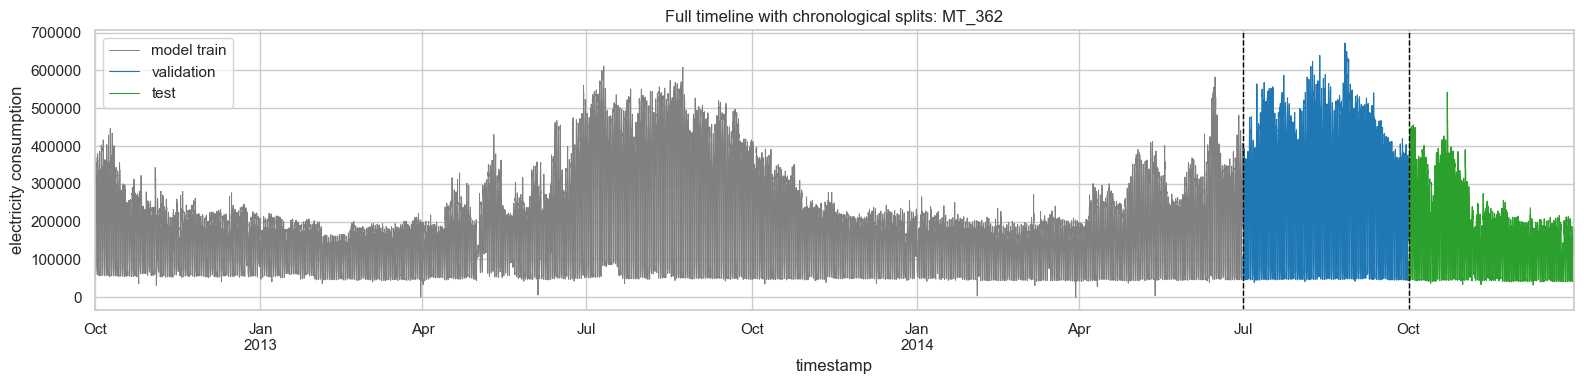

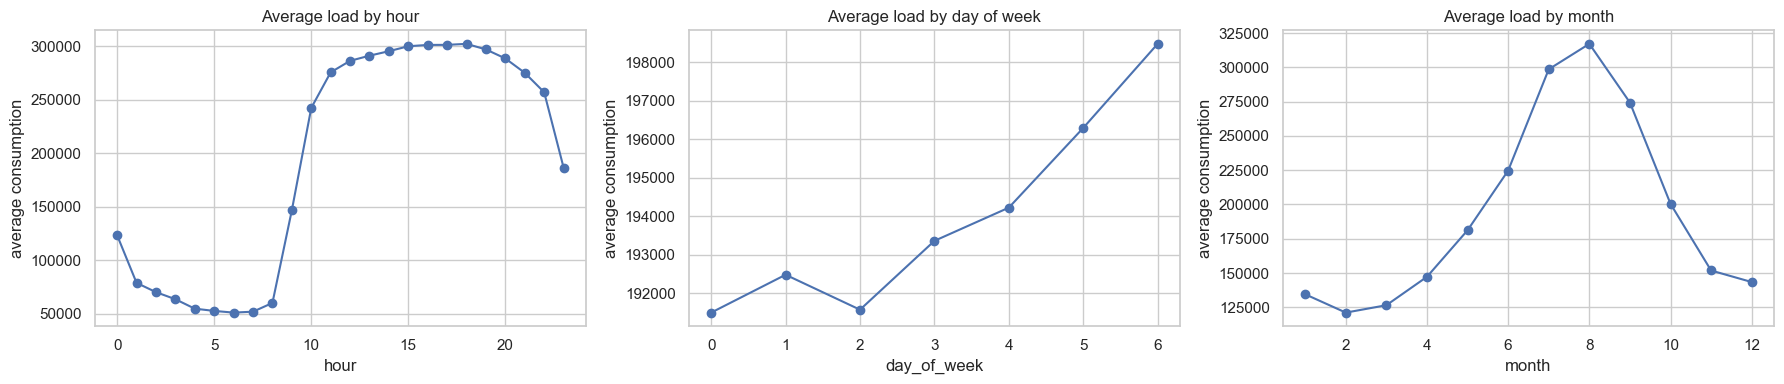

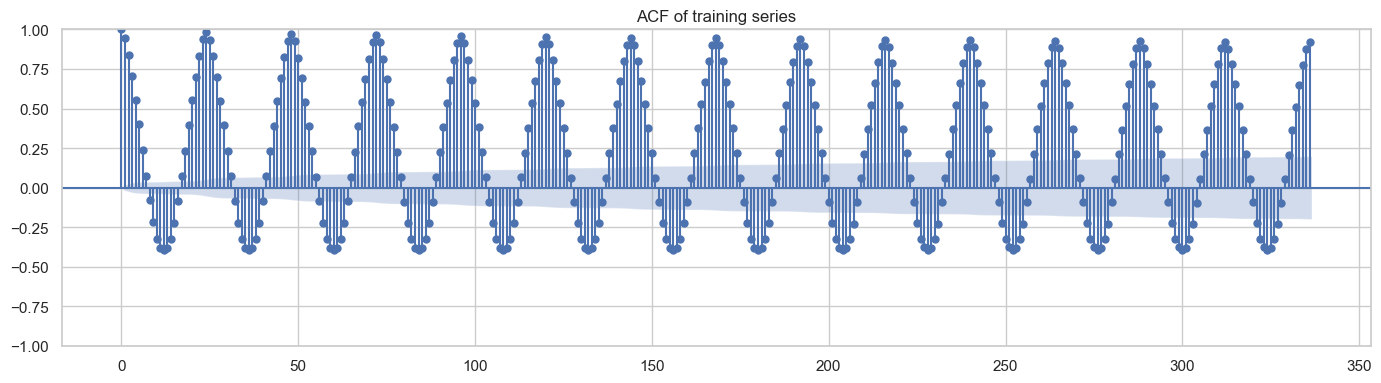

,diagnostic_value
hour_profile_max_min_ratio,5.909295
day_of_week_max_min_ratio,1.036495
month_max_min_ratio,2.616973
lag_1,0.947211
lag_24,0.984465
lag_168,0.954926


In [5]:
fig, ax = plt.subplots(figsize=(16, 4))
model_train_y.plot(ax=ax, label="model train", linewidth=0.7, color="#808080")
val_y.plot(ax=ax, label="validation", linewidth=0.8, color="#1f77b4")
test_y.plot(ax=ax, label="test", linewidth=0.8, color="#2ca02c")
ax.axvline(val_y.index.min(), color="black", linestyle="--", linewidth=1)
ax.axvline(test_y.index.min(), color="black", linestyle="--", linewidth=1)
ax.set_title(f"Full timeline with chronological splits: {TARGET_COLUMN}")
ax.set_ylabel("electricity consumption")
ax.legend()
savefig("01_full_timeline_splits.png")

profile = train_full.to_frame("load")
profile["hour"] = profile.index.hour
profile["day_of_week"] = profile.index.dayofweek
profile["month"] = profile.index.month

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
profile.groupby("hour")["load"].mean().plot(ax=axes[0], marker="o")
axes[0].set_title("Average load by hour")
profile.groupby("day_of_week")["load"].mean().plot(ax=axes[1], marker="o")
axes[1].set_title("Average load by day of week")
profile.groupby("month")["load"].mean().plot(ax=axes[2], marker="o")
axes[2].set_title("Average load by month")
for ax in axes:
    ax.set_ylabel("average consumption")
savefig("02_calendar_profiles.png")

fig, ax = plt.subplots(figsize=(14, 4))
plot_acf(train_full.dropna(), lags=min(24 * 14, len(train_full) // 2), ax=ax)
ax.set_title("ACF of training series")
savefig("03_acf_training_series.png")

acf_values = {
    "lag_1": train_full.autocorr(1),
    "lag_24": train_full.autocorr(24),
    "lag_168": train_full.autocorr(168),
}
trend_notes = pd.Series({
    "hour_profile_max_min_ratio": profile.groupby("hour")["load"].mean().max() / profile.groupby("hour")["load"].mean().min(),
    "day_of_week_max_min_ratio": profile.groupby("day_of_week")["load"].mean().max() / profile.groupby("day_of_week")["load"].mean().min(),
    "month_max_min_ratio": profile.groupby("month")["load"].mean().max() / profile.groupby("month")["load"].mean().min(),
    **acf_values,
})
display(trend_notes.to_frame("diagnostic_value"))


## 3. Direct Multi-Horizon Feature Engineering

For a forecast origin `t` and horizon `h`, the training target is `y(t+h)`. Features use only information available at origin `t`, plus known future calendar features for timestamp `t+h`. This avoids recursive forecasting and reduces the risk of producing a fixed repeated seasonal curve. The feature set intentionally avoids direct long-horizon linear trend extrapolation, because that made the October forecast level drop too aggressively.

In [6]:
def calendar_features_for_timestamp(ts: pd.Timestamp) -> dict:
    return {
        "target_hour": ts.hour,
        "target_day_of_week": ts.dayofweek,
        "target_month": ts.month,
        "target_is_weekend": int(ts.dayofweek >= 5),
        "target_sin_hour": np.sin(2 * np.pi * ts.hour / 24),
        "target_cos_hour": np.cos(2 * np.pi * ts.hour / 24),
        "target_sin_dow": np.sin(2 * np.pi * ts.dayofweek / 7),
        "target_cos_dow": np.cos(2 * np.pi * ts.dayofweek / 7),
    }


def origin_features(series: pd.Series, origin_pos: int, origin0: pd.Timestamp) -> dict:
    values = series.values.astype(float)
    idx = series.index
    ts = idx[origin_pos]
    row = {
        "origin_time_idx": float((ts - origin0) / pd.Timedelta(hours=1)),
        "origin_hour": ts.hour,
        "origin_day_of_week": ts.dayofweek,
        "origin_month": ts.month,
        "origin_is_weekend": int(ts.dayofweek >= 5),
        "last_value": values[origin_pos],
    }
    for lag in [1, 2, 3, 24, 48, 168, 336, 720]:
        row[f"lag_{lag}"] = values[origin_pos - lag] if origin_pos - lag >= 0 else np.nan
    for window in [24, 168, 720]:
        start = max(0, origin_pos - window + 1)
        vals = values[start:origin_pos + 1]
        row[f"rolling_mean_{window}"] = float(np.mean(vals))
        row[f"rolling_std_{window}"] = float(np.std(vals, ddof=1)) if len(vals) > 1 else 0.0
        row[f"rolling_min_{window}"] = float(np.min(vals))
        row[f"rolling_max_{window}"] = float(np.max(vals))
    row["recent_level_ratio_24_168"] = row["rolling_mean_24"] / row["rolling_mean_168"] if row["rolling_mean_168"] != 0 else 1.0
    row["recent_level_ratio_168_720"] = row["rolling_mean_168"] / row["rolling_mean_720"] if row["rolling_mean_720"] != 0 else 1.0
    row["recent_slope_168_720"] = (row["rolling_mean_168"] - row["rolling_mean_720"]) / 552.0
    return row


def make_direct_dataset(series: pd.Series, horizon: int, origin_step: int, max_rows=None):
    series = series.dropna().astype(float)
    origin0 = series.index.min()
    min_origin = max(720, horizon)
    max_origin = len(series) - horizon - 1
    if max_origin <= min_origin:
        raise ValueError("Not enough history to create direct multi-horizon training examples.")

    origins = list(range(min_origin, max_origin + 1, origin_step))
    rows = []
    y = []
    for origin_pos in origins:
        base = origin_features(series, origin_pos, origin0)
        for h in range(1, horizon + 1):
            target_pos = origin_pos + h
            target_ts = series.index[target_pos]
            row = dict(base)
            row["horizon"] = h
            row["horizon_day"] = h / 24.0
            row.update(calendar_features_for_timestamp(target_ts))
            rows.append(row)
            y.append(float(series.iloc[target_pos]))

    X = pd.DataFrame(rows).replace([np.inf, -np.inf], np.nan)
    y = pd.Series(y, name="target")
    data = X.join(y).dropna()
    if max_rows is not None and len(data) > max_rows:
        data = data.sample(n=max_rows, random_state=RANDOM_SEED).sort_index()
    return data.drop(columns="target"), data["target"], origin0


def make_direct_forecast_frame(history: pd.Series, future_index: pd.DatetimeIndex, feature_columns, origin0: pd.Timestamp):
    history = history.dropna().astype(float)
    origin_pos = len(history) - 1
    base = origin_features(history, origin_pos, origin0)
    rows = []
    for h, target_ts in enumerate(future_index, start=1):
        row = dict(base)
        row["horizon"] = h
        row["horizon_day"] = h / 24.0
        row.update(calendar_features_for_timestamp(target_ts))
        rows.append(row)
    X_future = pd.DataFrame(rows, index=future_index).replace([np.inf, -np.inf], np.nan)
    return X_future[feature_columns].fillna(0)

X_direct, y_direct, direct_origin0 = make_direct_dataset(
    model_train_y,
    horizon=forecast_horizon,
    origin_step=ORIGIN_STEP_HOURS,
    max_rows=MAX_DIRECT_TRAIN_ROWS,
)
print("Direct training matrix:", X_direct.shape)
display(X_direct.head())


Direct training matrix: (600000, 39)


,origin_time_idx,origin_hour,origin_day_of_week,origin_month,origin_is_weekend,last_value,lag_1,lag_2,lag_3,lag_24,...,horizon,horizon_day,target_hour,target_day_of_week,target_month,target_is_weekend,target_sin_hour,target_cos_hour,target_sin_dow,target_cos_dow
0,2208.0,0,1,1,0,84800.0,100300.0,150300.0,141100.0,133800.0,...,1,0.041667,1,1,1,0,0.258819,0.965926,0.781831,0.62349
2,2208.0,0,1,1,0,84800.0,100300.0,150300.0,141100.0,133800.0,...,3,0.125000,3,1,1,0,0.707107,0.707107,0.781831,0.62349
6,2208.0,0,1,1,0,84800.0,100300.0,150300.0,141100.0,133800.0,...,7,0.291667,7,1,1,0,0.965926,-0.258819,0.781831,0.62349
7,2208.0,0,1,1,0,84800.0,100300.0,150300.0,141100.0,133800.0,...,8,0.333333,8,1,1,0,0.866025,-0.500000,0.781831,0.62349
9,2208.0,0,1,1,0,84800.0,100300.0,150300.0,141100.0,133800.0,...,10,0.416667,10,1,1,0,0.500000,-0.866025,0.781831,0.62349


## 4. Naive Baseline

In [7]:

validation_predictions = {}
comparison_rows = []
rolling_validation_details = []


def rolling_score_naive(windows):
    rows = []
    for window in windows:
        pred = recursive_naive_forecast(window["history"], window["actual"].index)
        rows.append({
            "origin": window["origin"],
            "model": "naive",
            "mape": mape(window["actual"], pred),
        })
    return pd.DataFrame(rows)

naive_roll = rolling_score_naive(rolling_windows)
rolling_validation_details.append(naive_roll)
validation_predictions["naive"] = recursive_naive_forecast(model_train_y, val_y.index[:forecast_horizon])
comparison_rows.append({
    "model": "naive",
    "key_parameters": json.dumps({"strategy": "last observed value repeated"}),
    "validation_mape": float(naive_roll["mape"].mean()),
    "single_split_validation_mape": mape(val_y.iloc[:forecast_horizon], validation_predictions["naive"]),
    "justification": "Simple benchmark that repeats the most recent observed load; selected/evaluated by rolling-origin validation MAPE.",
})

display(naive_roll)
pd.DataFrame(comparison_rows)


,origin,model,mape
0,2014-04-30 23:00:00,naive,91.713841
1,2014-05-31 23:00:00,naive,89.763896
2,2014-06-30 23:00:00,naive,114.076031
3,2014-07-31 23:00:00,naive,123.969452
4,2014-08-31 23:00:00,naive,152.984130


,model,key_parameters,validation_mape,single_split_validation_mape,justification
0,naive,"{""strategy"": ""last observed value repeated""}",114.50147,113.553022,Simple benchmark that repeats the most recent ...


## 5. Direct Multi-Horizon LightGBM and XGBoost

The small parameter grids are selected to prevent overfitting and to keep model choices explainable. Selection uses validation MAPE only.

In [8]:

def evaluate_direct_model(model, history, future_y, feature_columns, origin0):
    X_future = make_direct_forecast_frame(history, future_y.index, feature_columns, origin0)
    pred = pd.Series(model.predict(X_future), index=X_future.index, name="prediction").clip(lower=0)
    return pred, mape(future_y, pred)


def build_direct_model(model_name: str, params: dict):
    if model_name == "direct_lightgbm":
        return LGBMRegressor(
            objective="regression",
            n_estimators=params["n_estimators"],
            learning_rate=params["learning_rate"],
            max_depth=params["max_depth"],
            num_leaves=params["num_leaves"],
            min_child_samples=params["min_child_samples"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            reg_lambda=params["reg_lambda"],
            random_state=RANDOM_SEED,
            n_jobs=-1,
            verbose=-1,
        )
    if model_name == "direct_xgboost":
        return XGBRegressor(
            objective="reg:squarederror",
            n_estimators=params["n_estimators"],
            max_depth=params["max_depth"],
            learning_rate=params["learning_rate"],
            subsample=params["subsample"],
            colsample_bytree=params["colsample_bytree"],
            reg_lambda=params["reg_lambda"],
            min_child_weight=params.get("min_child_weight", 1),
            random_state=RANDOM_SEED,
            n_jobs=-1,
            tree_method=params.get("tree_method", "hist"),
            verbosity=0,
        )
    raise ValueError(model_name)


def rolling_score_direct_model(model_name: str, params: dict, windows):
    rows = []
    for window in windows:
        X_roll, y_roll, origin0 = make_direct_dataset(
            window["history"],
            horizon=len(window["actual"]),
            origin_step=ORIGIN_STEP_HOURS,
            max_rows=MAX_DIRECT_TRAIN_ROWS,
        )
        model = build_direct_model(model_name, params)
        model.fit(X_roll, y_roll)
        pred, score = evaluate_direct_model(model, window["history"], window["actual"], X_roll.columns, origin0)
        rows.append({
            "origin": window["origin"],
            "model": model_name,
            "mape": score,
        })
    return pd.DataFrame(rows)


def full_validation_prediction_direct(model_name: str, params: dict):
    X_fit, y_fit, origin0 = make_direct_dataset(
        model_train_y,
        horizon=forecast_horizon,
        origin_step=ORIGIN_STEP_HOURS,
        max_rows=MAX_DIRECT_TRAIN_ROWS,
    )
    model = build_direct_model(model_name, params)
    model.fit(X_fit, y_fit)
    pred, score = evaluate_direct_model(model, model_train_y, val_y.iloc[:forecast_horizon], X_fit.columns, origin0)
    return pred, score

ml_records = []

lightgbm_param_grid = []
for n_estimators, max_depth, learning_rate, reg_lambda, min_child_samples in product([200, 500], [3], [0.03, 0.05], [1.0, 5.0], [80]):
    lightgbm_param_grid.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "num_leaves": 15,
        "min_child_samples": min_child_samples,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": reg_lambda,
    })

xgboost_param_grid = []
for n_estimators, max_depth, learning_rate, reg_lambda, min_child_weight in product([200, 500], [3], [0.03, 0.05], [1.0, 5.0], [10]):
    xgboost_param_grid.append({
        "n_estimators": n_estimators,
        "max_depth": max_depth,
        "learning_rate": learning_rate,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "reg_lambda": reg_lambda,
        "min_child_weight": min_child_weight,
        "tree_method": "hist",
    })

for model_name, param_grid in [("direct_lightgbm", lightgbm_param_grid), ("direct_xgboost", xgboost_param_grid)]:
    for params in param_grid:
        roll_df = rolling_score_direct_model(model_name, params, rolling_windows)
        rolling_validation_details.append(roll_df.assign(params=json.dumps(params)))
        rolling_score = float(roll_df["mape"].mean())
        ml_records.append({
            "model": model_name,
            "params": params,
            "validation_mape": rolling_score,
            "rolling_scores": roll_df,
        })
        print(f"{model_name} {params}: rolling validation MAPE={rolling_score:.3f}")

ml_results = pd.DataFrame([{k: v for k, v in r.items() if k != "rolling_scores"} for r in ml_records]).sort_values("validation_mape")
display(ml_results)

for model_name in ["direct_lightgbm", "direct_xgboost"]:
    best = min([r for r in ml_records if r["model"] == model_name], key=lambda r: r["validation_mape"])
    pred, single_split_score = full_validation_prediction_direct(model_name, best["params"])
    validation_predictions[model_name] = pred
    comparison_rows.append({
        "model": model_name,
        "key_parameters": json.dumps(best["params"]),
        "validation_mape": best["validation_mape"],
        "single_split_validation_mape": single_split_score,
        "justification": "Direct multi-horizon tree model with lag, rolling, calendar, horizon, and conservative trend-context features; selected by rolling-origin validation MAPE.",
    })


direct_lightgbm {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'num_leaves': 15, 'min_child_samples': 80, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0}: rolling validation MAPE=14.463
direct_lightgbm {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.03, 'num_leaves': 15, 'min_child_samples': 80, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 5.0}: rolling validation MAPE=14.591
direct_lightgbm {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 80, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 1.0}: rolling validation MAPE=13.868
direct_lightgbm {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.05, 'num_leaves': 15, 'min_child_samples': 80, 'subsample': 0.8, 'colsample_bytree': 0.8, 'reg_lambda': 5.0}: rolling validation MAPE=13.860
direct_lightgbm {'n_estimators': 500, 'max_depth': 3, 'learning_rate': 0.03, 'num_leaves': 15, 'min_child_samples': 80, 'subsample': 0.8, 'colsa

,model,params,validation_mape
14,direct_xgboost,"{'n_estimators': 500, 'max_depth': 3, 'learnin...",13.253876
10,direct_xgboost,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",13.496295
15,direct_xgboost,"{'n_estimators': 500, 'max_depth': 3, 'learnin...",13.558872
4,direct_lightgbm,"{'n_estimators': 500, 'max_depth': 3, 'learnin...",13.699870
5,direct_lightgbm,"{'n_estimators': 500, 'max_depth': 3, 'learnin...",13.818121
13,direct_xgboost,"{'n_estimators': 500, 'max_depth': 3, 'learnin...",13.836081
3,direct_lightgbm,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",13.859956
2,direct_lightgbm,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",13.868220
6,direct_lightgbm,"{'n_estimators': 500, 'max_depth': 3, 'learnin...",13.911545
11,direct_xgboost,"{'n_estimators': 200, 'max_depth': 3, 'learnin...",14.127194


## 6. Prophet Trend + Seasonality Model

Prophet is included because it explicitly models trend and multiple seasonal components. It is not expected to always beat tree models on high-frequency electricity data, but it gives a clear trend-aware statistical comparison.

In [9]:

def fit_prophet_forecast(train_series: pd.Series, future_index: pd.DatetimeIndex, params: dict) -> pd.Series:
    df = train_series.reset_index()
    df.columns = ["ds", "y"]
    model = Prophet(
        daily_seasonality=False,
        weekly_seasonality=False,
        yearly_seasonality=False,
        changepoint_prior_scale=params["changepoint_prior_scale"],
        seasonality_prior_scale=params["seasonality_prior_scale"],
        seasonality_mode=params["seasonality_mode"],
    )
    model.add_seasonality(name="daily", period=1, fourier_order=params["daily_fourier_order"])
    model.add_seasonality(name="weekly", period=7, fourier_order=params["weekly_fourier_order"])
    model.add_seasonality(name="yearly", period=365.25, fourier_order=params["yearly_fourier_order"])
    model.fit(df)
    future = pd.DataFrame({"ds": future_index})
    forecast = model.predict(future)
    pred = pd.Series(forecast["yhat"].values, index=future_index, name="prediction").clip(lower=0)
    return pred


def rolling_score_prophet(params: dict, windows):
    rows = []
    for window in windows:
        pred = fit_prophet_forecast(window["history"], window["actual"].index, params)
        rows.append({
            "origin": window["origin"],
            "model": "prophet",
            "mape": mape(window["actual"], pred),
        })
    return pd.DataFrame(rows)

prophet_records = []
if RUN_PROPHET:
    prophet_grid = [
        {"changepoint_prior_scale": 0.01, "seasonality_prior_scale": 5.0, "seasonality_mode": "additive", "daily_fourier_order": 10, "weekly_fourier_order": 5, "yearly_fourier_order": 5},
        {"changepoint_prior_scale": 0.05, "seasonality_prior_scale": 5.0, "seasonality_mode": "additive", "daily_fourier_order": 10, "weekly_fourier_order": 5, "yearly_fourier_order": 5},
        {"changepoint_prior_scale": 0.10, "seasonality_prior_scale": 10.0, "seasonality_mode": "additive", "daily_fourier_order": 10, "weekly_fourier_order": 5, "yearly_fourier_order": 5},
        {"changepoint_prior_scale": 0.05, "seasonality_prior_scale": 5.0, "seasonality_mode": "multiplicative", "daily_fourier_order": 10, "weekly_fourier_order": 5, "yearly_fourier_order": 5},
    ]
    for params in prophet_grid:
        try:
            roll_df = rolling_score_prophet(params, rolling_windows)
            rolling_validation_details.append(roll_df.assign(params=json.dumps(params)))
            rolling_score = float(roll_df["mape"].mean())
            prophet_records.append({"model": "prophet", "params": params, "validation_mape": rolling_score, "rolling_scores": roll_df})
            print(f"Prophet {params}: rolling validation MAPE={rolling_score:.3f}")
        except Exception as exc:
            print(f"Prophet failed for {params}: {type(exc).__name__}: {exc}")
else:
    print("RUN_PROPHET is False; skipping Prophet.")

prophet_results = pd.DataFrame([{k: v for k, v in r.items() if k != "rolling_scores"} for r in prophet_records]).sort_values("validation_mape") if prophet_records else pd.DataFrame()
display(prophet_results)

if prophet_records:
    best_prophet = min(prophet_records, key=lambda r: r["validation_mape"])
    pred = fit_prophet_forecast(model_train_y, val_y.index[:forecast_horizon], best_prophet["params"])
    validation_predictions["prophet"] = pred
    comparison_rows.append({
        "model": "prophet",
        "key_parameters": json.dumps(best_prophet["params"]),
        "validation_mape": best_prophet["validation_mape"],
        "single_split_validation_mape": mape(val_y.iloc[:forecast_horizon], pred),
        "justification": "Explicit trend plus daily, weekly, and yearly seasonality model; selected by rolling-origin validation MAPE from a small grid.",
    })


15:27:18 - cmdstanpy - INFO - Chain [1] start processing
15:27:19 - cmdstanpy - INFO - Chain [1] done processing
15:27:19 - cmdstanpy - INFO - Chain [1] start processing
15:27:20 - cmdstanpy - INFO - Chain [1] done processing
15:27:20 - cmdstanpy - INFO - Chain [1] start processing
15:27:21 - cmdstanpy - INFO - Chain [1] done processing
15:27:21 - cmdstanpy - INFO - Chain [1] start processing
15:27:22 - cmdstanpy - INFO - Chain [1] done processing
15:27:22 - cmdstanpy - INFO - Chain [1] start processing
15:27:23 - cmdstanpy - INFO - Chain [1] done processing


Prophet {'changepoint_prior_scale': 0.01, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive', 'daily_fourier_order': 10, 'weekly_fourier_order': 5, 'yearly_fourier_order': 5}: rolling validation MAPE=60.799


15:27:23 - cmdstanpy - INFO - Chain [1] start processing
15:27:23 - cmdstanpy - INFO - Chain [1] done processing
15:27:24 - cmdstanpy - INFO - Chain [1] start processing
15:27:24 - cmdstanpy - INFO - Chain [1] done processing
15:27:25 - cmdstanpy - INFO - Chain [1] start processing
15:27:26 - cmdstanpy - INFO - Chain [1] done processing
15:27:27 - cmdstanpy - INFO - Chain [1] start processing
15:27:27 - cmdstanpy - INFO - Chain [1] done processing
15:27:28 - cmdstanpy - INFO - Chain [1] start processing
15:27:29 - cmdstanpy - INFO - Chain [1] done processing


Prophet {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'additive', 'daily_fourier_order': 10, 'weekly_fourier_order': 5, 'yearly_fourier_order': 5}: rolling validation MAPE=59.226


15:27:30 - cmdstanpy - INFO - Chain [1] start processing
15:27:31 - cmdstanpy - INFO - Chain [1] done processing
15:27:31 - cmdstanpy - INFO - Chain [1] start processing
15:27:32 - cmdstanpy - INFO - Chain [1] done processing
15:27:33 - cmdstanpy - INFO - Chain [1] start processing
15:27:34 - cmdstanpy - INFO - Chain [1] done processing
15:27:35 - cmdstanpy - INFO - Chain [1] start processing
15:27:36 - cmdstanpy - INFO - Chain [1] done processing
15:27:37 - cmdstanpy - INFO - Chain [1] start processing
15:27:38 - cmdstanpy - INFO - Chain [1] done processing


Prophet {'changepoint_prior_scale': 0.1, 'seasonality_prior_scale': 10.0, 'seasonality_mode': 'additive', 'daily_fourier_order': 10, 'weekly_fourier_order': 5, 'yearly_fourier_order': 5}: rolling validation MAPE=56.876


15:27:39 - cmdstanpy - INFO - Chain [1] start processing
15:27:43 - cmdstanpy - INFO - Chain [1] done processing
15:27:44 - cmdstanpy - INFO - Chain [1] start processing
15:27:48 - cmdstanpy - INFO - Chain [1] done processing
15:27:49 - cmdstanpy - INFO - Chain [1] start processing
15:27:52 - cmdstanpy - INFO - Chain [1] done processing
15:27:52 - cmdstanpy - INFO - Chain [1] start processing
15:27:57 - cmdstanpy - INFO - Chain [1] done processing
15:27:58 - cmdstanpy - INFO - Chain [1] start processing
15:28:02 - cmdstanpy - INFO - Chain [1] done processing


Prophet {'changepoint_prior_scale': 0.05, 'seasonality_prior_scale': 5.0, 'seasonality_mode': 'multiplicative', 'daily_fourier_order': 10, 'weekly_fourier_order': 5, 'yearly_fourier_order': 5}: rolling validation MAPE=20.047


,model,params,validation_mape
3,prophet,"{'changepoint_prior_scale': 0.05, 'seasonality...",20.046936
2,prophet,"{'changepoint_prior_scale': 0.1, 'seasonality_...",56.875561
1,prophet,"{'changepoint_prior_scale': 0.05, 'seasonality...",59.225827
0,prophet,"{'changepoint_prior_scale': 0.01, 'seasonality...",60.798673


15:28:02 - cmdstanpy - INFO - Chain [1] start processing
15:28:05 - cmdstanpy - INFO - Chain [1] done processing


## 7. Validation Comparison and Model Selection

In [10]:
comparison = pd.DataFrame(comparison_rows).sort_values("validation_mape").reset_index(drop=True)
comparison.to_parquet(OUTPUT_DIR / "model_comparison_validation.parquet", index=False, engine="pyarrow")
rolling_validation_details_df = pd.concat(rolling_validation_details, ignore_index=True) if rolling_validation_details else pd.DataFrame()
rolling_validation_details_df.to_parquet(OUTPUT_DIR / "rolling_validation_details.parquet", index=False, engine="pyarrow")
display(comparison)
display(rolling_validation_details_df.head(20))

best_model_name = comparison.loc[0, "model"]
print(f"Selected final model by validation MAPE only: {best_model_name}")


,model,key_parameters,validation_mape,single_split_validation_mape,justification
0,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",13.253876,14.364054,"Direct multi-horizon tree model with lag, roll..."
1,direct_lightgbm,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",13.699870,15.847145,"Direct multi-horizon tree model with lag, roll..."
2,prophet,"{""changepoint_prior_scale"": 0.05, ""seasonality...",20.046936,21.333887,"Explicit trend plus daily, weekly, and yearly ..."
3,naive,"{""strategy"": ""last observed value repeated""}",114.501470,113.553022,Simple benchmark that repeats the most recent ...


,origin,model,mape,params
0,2014-04-30 23:00:00,naive,91.713841,NaN
1,2014-05-31 23:00:00,naive,89.763896,NaN
2,2014-06-30 23:00:00,naive,114.076031,NaN
3,2014-07-31 23:00:00,naive,123.969452,NaN
4,2014-08-31 23:00:00,naive,152.984130,NaN
5,2014-04-30 23:00:00,direct_lightgbm,26.846003,"{""n_estimators"": 200, ""max_depth"": 3, ""learnin..."
6,2014-05-31 23:00:00,direct_lightgbm,13.879661,"{""n_estimators"": 200, ""max_depth"": 3, ""learnin..."
7,2014-06-30 23:00:00,direct_lightgbm,13.036572,"{""n_estimators"": 200, ""max_depth"": 3, ""learnin..."
8,2014-07-31 23:00:00,direct_lightgbm,11.148551,"{""n_estimators"": 200, ""max_depth"": 3, ""learnin..."
9,2014-08-31 23:00:00,direct_lightgbm,7.402412,"{""n_estimators"": 200, ""max_depth"": 3, ""learnin..."


Selected final model by validation MAPE only: direct_xgboost


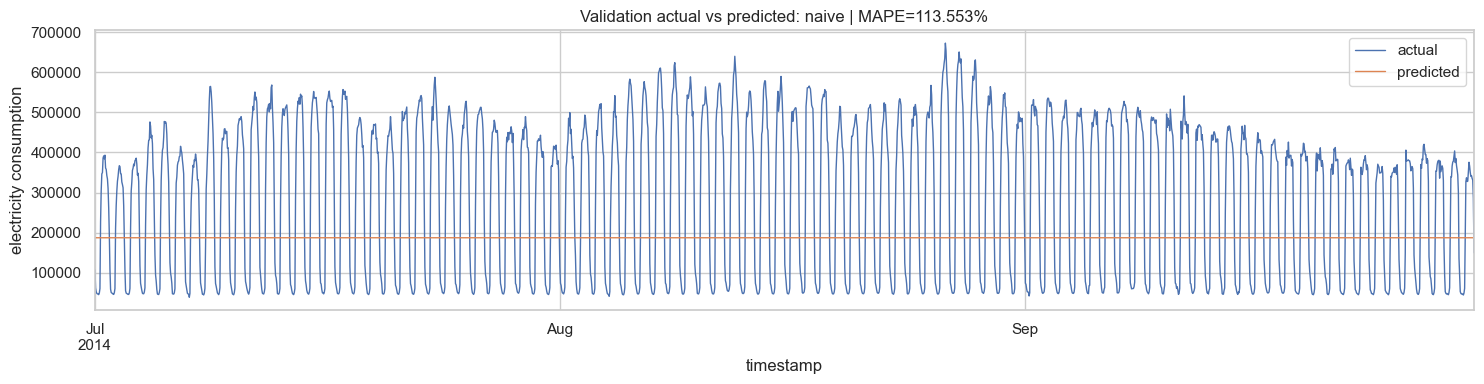

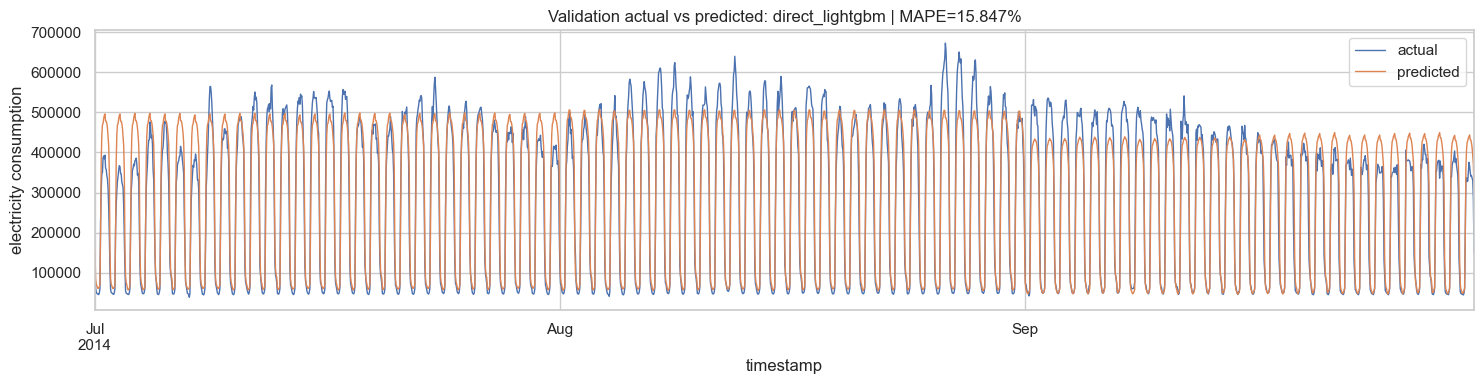

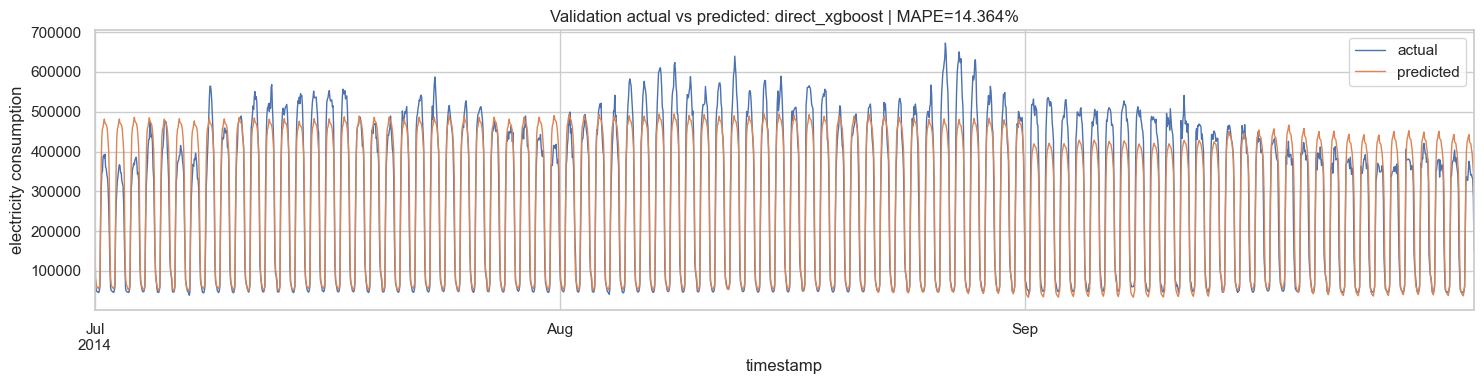

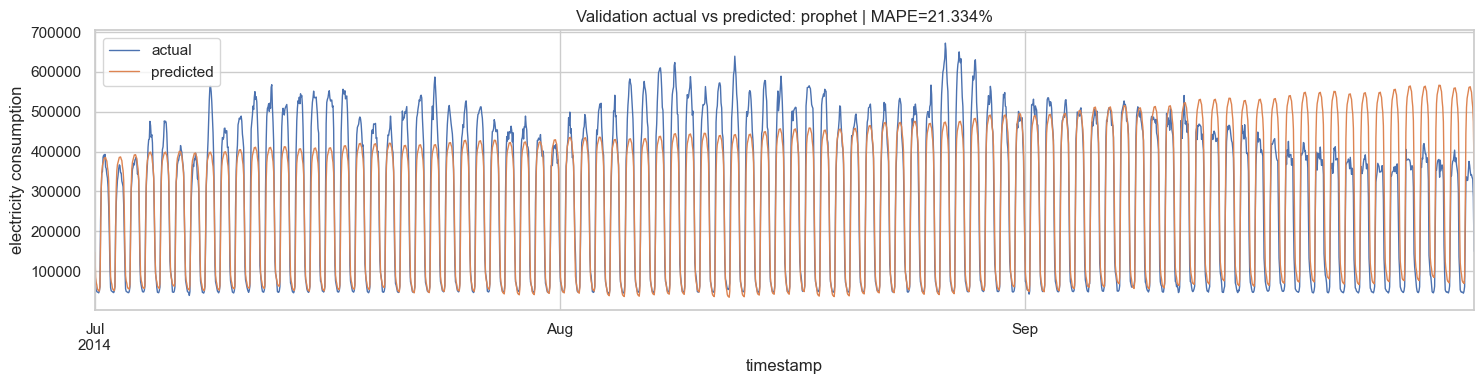

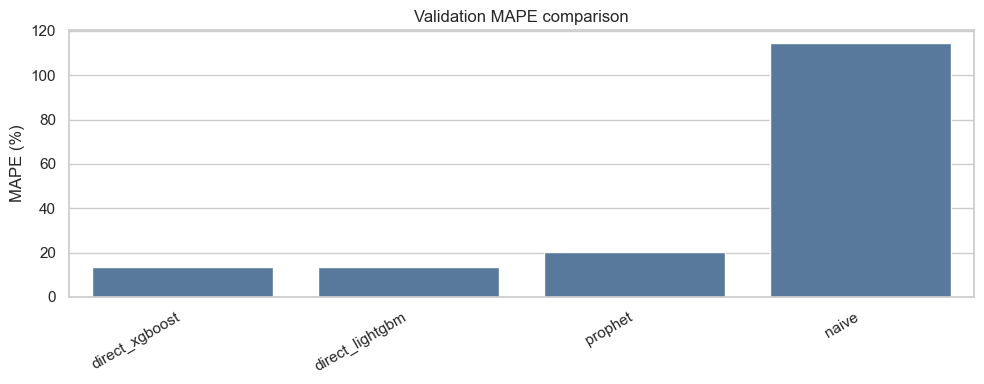

PosixPath('/Users/qrange77/Desktop/Forecasting/Proj2/Electricity-Load-Prediction/cluster6/artifacts/plots/direct_trend/validation_mape_comparison.png')

In [11]:
for name, pred in validation_predictions.items():
    fig, ax = plt.subplots(figsize=(15, 4))
    val_y.iloc[:forecast_horizon].plot(ax=ax, label="actual", linewidth=1.0)
    pred.plot(ax=ax, label="predicted", linewidth=1.0)
    ax.set_title(f"Validation actual vs predicted: {name} | MAPE={mape(val_y.iloc[:forecast_horizon], pred):.3f}%")
    ax.set_ylabel("electricity consumption")
    ax.legend()
    savefig(f"validation_actual_vs_predicted_{name}.png")

fig, ax = plt.subplots(figsize=(10, 4))
sns.barplot(data=comparison, x="model", y="validation_mape", color="#4c78a8", ax=ax)
ax.set_title("Validation MAPE comparison")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("")
plt.xticks(rotation=30, ha="right")
savefig("validation_mape_comparison.png")


## 8. Final Test Evaluation

The selected model is refit on train + validation and evaluated once on test. The test set is not used for parameter tuning or model selection.

In [12]:

def refit_direct_model(model_name: str, params: dict, history: pd.Series, test_index: pd.DatetimeIndex):
    X_full, y_full, origin0 = make_direct_dataset(
        history,
        horizon=len(test_index),
        origin_step=ORIGIN_STEP_HOURS,
        max_rows=MAX_DIRECT_TRAIN_ROWS,
    )
    model = build_direct_model(model_name, params)
    model.fit(X_full, y_full)
    X_test = make_direct_forecast_frame(history, test_index, X_full.columns, origin0)
    pred = pd.Series(model.predict(X_test), index=test_index, name="prediction").clip(lower=0)
    return pred

selected_params = json.loads(comparison.loc[0, "key_parameters"])
history_for_final = train_full.copy()

if best_model_name == "naive":
    final_test_pred = recursive_naive_forecast(history_for_final, test_y.index)
elif best_model_name in {"direct_lightgbm", "direct_xgboost"}:
    final_test_pred = refit_direct_model(best_model_name, selected_params, history_for_final, test_y.index)
elif best_model_name == "prophet":
    final_test_pred = fit_prophet_forecast(history_for_final, test_y.index, selected_params)
else:
    raise ValueError(best_model_name)

final_test_mape = mape(test_y, final_test_pred)
final_test_eval_metrics = evaluate_tft_style_metrics(test_y, final_test_pred)
final_results = pd.DataFrame([{
    "selected_model": best_model_name,
    "selected_parameters": json.dumps(selected_params),
    "rolling_validation_mape": float(comparison.loc[0, "validation_mape"]),
    "single_split_validation_mape": float(comparison.loc[0, "single_split_validation_mape"]),
    "test_mape": final_test_mape,
    "test_mape_0_100": final_test_eval_metrics["MAPE_0_100"],
    "test_epsilon_mape_pct": final_test_eval_metrics["EPSILON_MAPE_PCT"],
    "test_wmape_0_100": final_test_eval_metrics["WMAPE_0_100"],
    "test_n_obs": final_test_eval_metrics["n_obs"],
    "test_n_positive": final_test_eval_metrics["n_positive"],
    "mape_epsilon": MAPE_EPSILON,
    "selection_rule": "lowest rolling-origin validation MAPE only",
}])
final_results.to_parquet(OUTPUT_DIR / "final_test_results.parquet", index=False, engine="pyarrow")
display(final_results)


,selected_model,selected_parameters,rolling_validation_mape,single_split_validation_mape,test_mape,test_mape_0_100,test_epsilon_mape_pct,test_wmape_0_100,test_n_obs,test_n_positive,mape_epsilon,selection_rule
0,direct_xgboost,"{""n_estimators"": 500, ""max_depth"": 3, ""learnin...",13.253876,14.364054,15.650182,15.650182,15.650182,15.414158,2208,2208,0.000001,lowest rolling-origin validation MAPE only


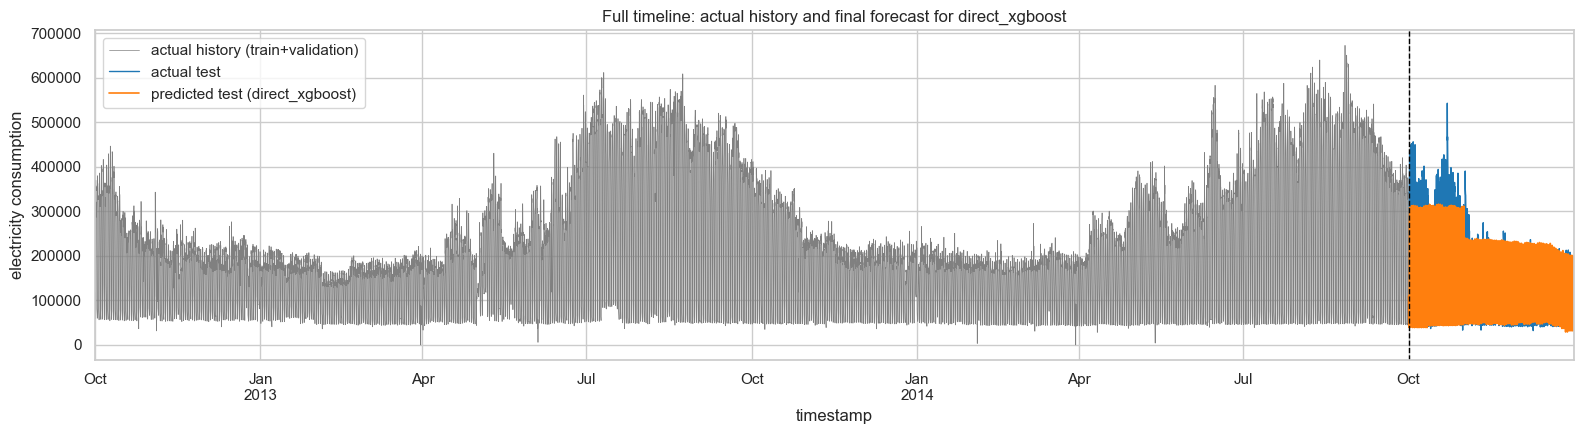

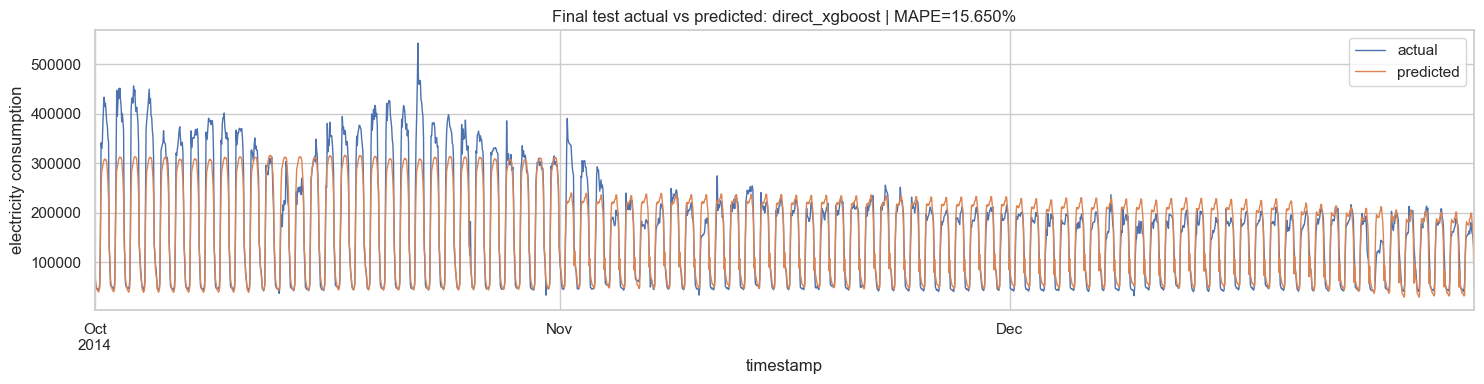

In [13]:
fig, ax = plt.subplots(figsize=(16, 4.5))
train_full.plot(ax=ax, label="actual history (train+validation)", linewidth=0.5, color="#808080")
test_y.plot(ax=ax, label="actual test", linewidth=1.0, color="#1f77b4")
final_test_pred.plot(ax=ax, label=f"predicted test ({best_model_name})", linewidth=1.2, color="#ff7f0e")
ax.axvline(test_y.index.min(), color="black", linestyle="--", linewidth=1)
ax.set_title(f"Full timeline: actual history and final forecast for {best_model_name}")
ax.set_ylabel("electricity consumption")
ax.legend()
savefig("final_full_timeline_forecast.png")

fig, ax = plt.subplots(figsize=(15, 4))
test_y.plot(ax=ax, label="actual", linewidth=1.0)
final_test_pred.plot(ax=ax, label="predicted", linewidth=1.0)
ax.set_title(f"Final test actual vs predicted: {best_model_name} | MAPE={final_test_mape:.3f}%")
ax.set_ylabel("electricity consumption")
ax.legend()
savefig("test_actual_vs_predicted_final_model.png")

epsilon_ape = epsilon_ape_pct(test_y, final_test_pred)
ape_table = pd.DataFrame({
    "timestamp": test_y.index,
    "actual": test_y.values,
    "prediction": final_test_pred.values,
    "ape_pct": ape_pct(test_y, final_test_pred).values,
    "epsilon_ape_pct": epsilon_ape.values,
    "ape_pct_0_100": epsilon_ape.clip(lower=0.0, upper=100.0).values,
})
ape_table.to_parquet(OUTPUT_DIR / "final_test_forecast_detail.parquet", index=False, engine="pyarrow")
